#MODULE 2: INTERPRETABLE MODELS
## 2.1 LINEAR MODELS INTERPRETATION




### 2.1.1 LINEAR REGRESSION (nice one)

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt





In [2]:
df = pd.read_csv('body-fat-brozek.csv')
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   body fat brozek  252 non-null    float64
 1   age              252 non-null    int64  
 2   weight           252 non-null    float64
 3   height           252 non-null    float64
 4   adiposity        252 non-null    float64
 5   neck             252 non-null    float64
 6   chest            252 non-null    float64
 7   abdomen          252 non-null    float64
 8   hip              252 non-null    float64
 9   tight            252 non-null    float64
 10  knee             252 non-null    float64
 11  ankle            252 non-null    float64
 12  biceps           252 non-null    float64
 13  forearm          252 non-null    float64
 14  wrist            252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


,body fat brozek,age,weight,height,adiposity,neck,chest,abdomen,hip,tight,knee,ankle,biceps,forearm,wrist
0,12.6,23,154.25,67.75,23.7,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,6.9,22,173.25,72.25,23.4,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,24.6,22,154.00,66.25,24.7,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,10.9,26,184.75,72.25,24.9,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,27.8,24,184.25,71.25,25.6,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [3]:
## BUILD THE LINEAR REGRESSION MODEL

# 1. Prepare data

# Separate features (X) and target variable (y)
X = df.drop(columns=['body fat brozek'])
y = df[['body fat brozek']]




# 2. Create and train the model
model = LinearRegression()
model.fit(X, y)
betas = model.coef_
beta_0 = model.intercept_
residuals = y-model.predict(X)

print('Beta_0: ', beta_0, "(intercept)")
print('Beta_1: ', betas)
print('Epsilon (error): ', residuals)


Beta_0:  [-15.19014138] (intercept)
Beta_1:  [[ 5.68794841e-02 -8.13021517e-02 -5.30707049e-02  6.10056484e-02
  -4.44964400e-01 -3.08669641e-02  8.78976885e-01 -2.03066130e-01
   2.27376830e-01 -9.92652159e-04  1.57206638e-01  1.48511181e-01
   4.29668083e-01 -1.47925255e+00]]
Epsilon (error):       body fat brozek
0          -3.596256
1          -2.574192
2           6.201186
3          -1.396460
4           1.326999
..               ...
247        -3.377168
248         7.197438
249        -7.139937
250         1.336022
251         4.164291

[252 rows x 1 columns]


### 2.2.2 INTERPRETING LINEAR REGRESSION


### Visualization

In [4]:
beta_idx = np.argmax(np.abs(betas))
beta_idx

13

In [5]:
beta_max = betas[0][beta_idx]
beta_max

-1.479252551420465

El atributo que más cotribuye es "wrist".

In [6]:
# Calcular la matriz de correlación
correlation_matrix = df.corr()

# Mostrar la matriz de correlación
print("Matriz de correlación:")
print(correlation_matrix)

Matriz de correlación:
                 body fat brozek       age    weight    height  adiposity  \
body fat brozek         1.000000  0.289174  0.613156 -0.089106   0.727994   
age                     0.289174  1.000000 -0.012746 -0.171645   0.118851   
weight                  0.613156 -0.012746  1.000000  0.308279   0.887352   
height                 -0.089106 -0.171645  0.308279  1.000000  -0.024891   
adiposity               0.727994  0.118851  0.887352 -0.024891   1.000000   
neck                    0.491489  0.113505  0.830716  0.253710   0.777857   
chest                   0.702885  0.176450  0.894191  0.134892   0.911799   
abdomen                 0.813706  0.230409  0.887995  0.087813   0.923880   
hip                     0.625700 -0.050332  0.940884  0.170394   0.883269   
tight                   0.561284 -0.200096  0.868694  0.148436   0.812706   
knee                    0.507786  0.017516  0.853167  0.286053   0.713660   
ankle                   0.266783 -0.105058  0.613685 

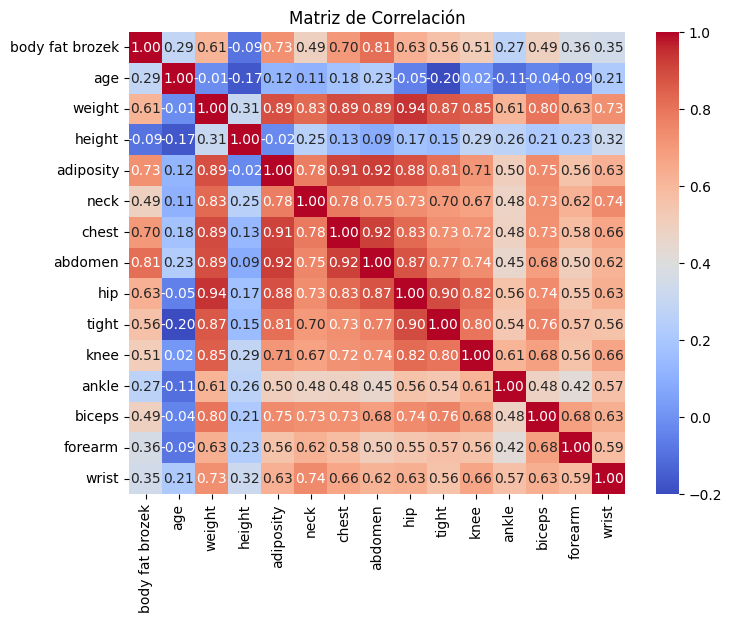

In [7]:
# Crear un mapa de calor de la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

Relaciones de regresión linear:


*   1: No se cumple el que haya una relación lineal debido a que hay algunas features que no tienen mucha relación con el clase target ('age',height'). Hay otras features que sí la tienen como por ejemplo 'abdomen'.
*   4: No se cumple que no haya una fuerte correlación entre features (weight y hip o adiposity y abdomen).



### Standard Error

In [8]:
# Calculate the standard error of the regression
n = len(y)  # Number of observations
p = X.shape[1]  # Number of predictors (features)
standard_error = np.sqrt(np.sum(residuals**2) / (n - p - 1))

print("SE", standard_error)

type(standard_error) #series

SE body fat brozek    3.995972
dtype: float64


pandas.core.series.Series

### Statistic |t| - value

In [12]:
# Calculate standard errors of the coefficients
# Assuming X is standardized (mean=0, variance=1) for simplicity
# If not, you'll need to calculate the variance-covariance matrix of the coefficients
coef_se = standard_error / np.sqrt(n)
print(coef_se)

# Calculate t-statistics
t_statistics_0 = betas[0][0] / coef_se
print("|t|", t_statistics_0)
t_statistics_1 = betas[0][1] / coef_se
print("|t|", t_statistics_1)
t_statistics_2 = betas[0][2] / coef_se
print("|t|", t_statistics_2)
t_statistics_3 = betas[0][3] / coef_se
print("|t|", t_statistics_3)
t_statistics_4 = betas[0][4] / coef_se
print("|t|", t_statistics_4)
t_statistics_5 = betas[0][5] / coef_se
print("|t|", t_statistics_5)
t_statistics_6 = betas[0][6] / coef_se
print("|t|", t_statistics_6)
t_statistics_7 = betas[0][7] / coef_se
print("|t|", t_statistics_7)
t_statistics_8 = betas[0][8] / coef_se
print("|t|", t_statistics_8)
t_statistics_9 = betas[0][9] / coef_se
print("|t|", t_statistics_9)
t_statistics_10 = betas[0][10] / coef_se
print("|t|", t_statistics_10)
t_statistics_11 = betas[0][11] / coef_se
print("|t|", t_statistics_11)
t_statistics_12 = betas[0][12] / coef_se
print("|t|", t_statistics_12)
t_statistics_13 = betas[0][13] / coef_se
print("|t|", t_statistics_13)

body fat brozek    0.251723
dtype: float64
|t| body fat brozek    0.225961
dtype: float64
|t| body fat brozek   -0.322983
dtype: float64
|t| body fat brozek   -0.21083
dtype: float64
|t| body fat brozek    0.242353
dtype: float64
|t| body fat brozek   -1.767678
dtype: float64
|t| body fat brozek   -0.122623
dtype: float64
|t| body fat brozek    3.491848
dtype: float64
|t| body fat brozek   -0.806706
dtype: float64
|t| body fat brozek    0.903283
dtype: float64
|t| body fat brozek   -0.003943
dtype: float64
|t| body fat brozek    0.624523
dtype: float64
|t| body fat brozek    0.58998
dtype: float64
|t| body fat brozek    1.706911
dtype: float64
|t| body fat brozek   -5.876519
dtype: float64


En base a los estadísticos podemos decir que se confirma lo obtenido con las betas, donde 'wrist' es la más importante con un 5.87.

### Statistic p-value

In [15]:
t_statistics = [t_statistics_0, t_statistics_1, t_statistics_2, t_statistics_3, t_statistics_4, t_statistics_5, t_statistics_6,
                t_statistics_7, t_statistics_8, t_statistics_9, t_statistics_10, t_statistics_11, t_statistics_12, t_statistics_13]

# Calculate p-values
p_values = 2 * (1 - stats.t.cdf(np.abs(t_statistics), df=n - p - 1))

print('p-values',p_values)
type(p_values) #series


p-values [[8.21426497e-01]
 [7.46992769e-01]
 [8.33200978e-01]
 [8.08716460e-01]
 [7.84015129e-02]
 [9.02509597e-01]
 [5.72061779e-04]
 [4.20644617e-01]
 [3.67292654e-01]
 [9.96856918e-01]
 [5.32884644e-01]
 [5.55766393e-01]
 [8.91482939e-02]
 [1.41194965e-08]]


numpy.ndarray

En base al p-value, el más importante sigue siendo 'wrist', por tener el p-value más bajo.